# EY AI & Data Challenge 2026 - Water Quality Prediction in South Africa

## Challenge Overview

**Objectif** : Prédire 3 paramètres de qualité de l'eau en Afrique du Sud
- **Total Alkalinity (TA)** - Alcalinité totale
- **Electrical Conductance (EC)** - Conductivité électrique
- **Dissolved Reactive Phosphorus (DRP)** - Phosphore réactif dissous

**Période** : 2011-2015 | **Sites** : ~200 stations riveraines

**Stratégie** :
1. Exploration des données (EDA)
2. Feature Engineering avancé
3. Modélisation multi-algorithmes avec GroupKFold (anti-overfitting spatial)
4. Interprétabilité et validation

## Etape 1 : Import des Librairies

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial
import geopandas as gpd
from scipy.spatial import cKDTree

# Machine Learning - Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, GroupKFold, cross_validate
from sklearn.pipeline import Pipeline

# Machine Learning - Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Advanced ML (optional - installer si besoin)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except:
    XGBOOST_AVAILABLE = False
    print(" XGBoost non disponible - pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except:
    LIGHTGBM_AVAILABLE = False
    print(" LightGBM non disponible - pip install lightgbm")

try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False
    print(" SHAP non disponible - pip install shap")

# Autres
from datetime import datetime
from tqdm import tqdm
import os

print(" Librairies importées avec succès!")
print(f"XGBoost: {XGBOOST_AVAILABLE} | LightGBM: {LIGHTGBM_AVAILABLE} | SHAP: {SHAP_AVAILABLE}")

 Librairies importées avec succès!
XGBoost: True | LightGBM: True | SHAP: True


In [2]:
# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Seed pour reproductibilité
np.random.seed(42)

## Etape 2 : Chargement des Données

Nous allons charger les 3 datasets principaux :
1. **water_quality_training_dataset.csv** : Variables cibles (TA, EC, DRP)
2. **landsat_features_training.csv** : Features satellites (bandes spectrales + indices)
3. **terraclimate_features_training.csv** : Features climatiques (PET)

In [3]:
# Chemin vers les données
data_path = 'Jupyter Notebook Package/'

# 1. Charger les données de qualité de l'eau (variables cibles)
water_quality_df = pd.read_csv(os.path.join(data_path, 'water_quality_training_dataset.csv'))
print(f" Water Quality: {water_quality_df.shape}")

# 2. Charger les features Landsat
landsat_train = pd.read_csv(os.path.join(data_path, 'landsat_features_training.csv'))
print(f" Landsat Train: {landsat_train.shape}")

# 3. Charger les features TerraClimate
terraclimate_train = pd.read_csv(os.path.join(data_path, 'terraclimate_features_training.csv'))
print(f" TerraClimate Train: {terraclimate_train.shape}")

print("\nAperçu Water Quality:")
water_quality_df.head()

 Water Quality: (9319, 6)
 Landsat Train: (9319, 9)
 TerraClimate Train: (9319, 4)

Aperçu Water Quality:


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0


In [4]:
# Aperçu Landsat features
print("Aperçu Landsat Features:")
print(landsat_train.head())
print(f"\nColonnes: {landsat_train.columns.tolist()}") 

Aperçu Landsat Features:
    Latitude  Longitude Sample Date      nir    green   swir16   swir22  \
0 -28.760833  17.730278  02-01-2011  11190.0  11426.0   7687.5   7645.0   
1 -26.861111  28.884722  03-01-2011  17658.5   9550.0  13746.5  10574.0   
2 -26.450000  28.085833  03-01-2011  15210.0  10720.0  17974.0  14201.0   
3 -27.671111  27.236944  03-01-2011  14887.0  10943.0  13522.0  11403.0   
4 -27.356667  27.286389  03-01-2011  16828.5   9502.5  12665.5   9643.0   

       NDMI     MNDWI  
0  0.185538  0.195595  
1  0.124566 -0.180134  
2 -0.083293 -0.252805  
3  0.048048 -0.105416  
4  0.141147 -0.142683  

Colonnes: ['Latitude', 'Longitude', 'Sample Date', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI']


In [5]:
# Aperçu TerraClimate features
print("Aperçu TerraClimate Features:")
print(terraclimate_train.head())
print(f"\nColonnes: {terraclimate_train.columns.tolist()}") 

Aperçu TerraClimate Features:
    Latitude  Longitude Sample Date    pet
0 -28.760833  17.730278  02-01-2011  174.2
1 -26.861111  28.884722  03-01-2011  124.1
2 -26.450000  28.085833  03-01-2011  127.5
3 -27.671111  27.236944  03-01-2011  129.7
4 -27.356667  27.286389  03-01-2011  129.2

Colonnes: ['Latitude', 'Longitude', 'Sample Date', 'pet']


### Fusion des Datasets

Nous allons fusionner les 3 datasets sur les colonnes communes : **Latitude**, **Longitude**, et **Sample Date**

In [6]:
# Fusion des datasets
# Colonnes de jointure
merge_cols = ['Latitude', 'Longitude', 'Sample Date']

# Étape 1: Fusionner water_quality avec landsat
df = water_quality_df.merge(landsat_train, on=merge_cols, how='inner')
print(f"Après fusion avec Landsat: {df.shape}")

# Étape 2: Fusionner avec terraclimate
df = df.merge(terraclimate_train, on=merge_cols, how='inner')
print(f"Après fusion avec TerraClimate: {df.shape}")

print("\n Dataset complet créé!")
print(f"Colonnes: {df.columns.tolist()}")
df.head()

Après fusion avec Landsat: (9319, 12)
Après fusion avec TerraClimate: (9319, 13)

 Dataset complet créé!
Colonnes: ['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'pet']


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,nir,green,swir16,swir22,NDMI,MNDWI,pet
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595,174.2
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,124.1
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805,127.5
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416,129.7
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683,129.2


## Etape 3 : Exploratory Data Analysis (EDA)

Analyse approfondie des données pour comprendre :
- Distributions des 3 paramètres cibles
- Valeurs manquantes
- Corrélations entre features
- Patterns géographiques et temporels

In [7]:
# Informations générales du dataset
print("="*60)
print("INFORMATIONS GÉNÉRALES")
print("="*60)
print(f"Nombre d'échantillons: {len(df)}")
print(f"Nombre de features: {len(df.columns)}")
print(f"Période: {df['Sample Date'].min()} → {df['Sample Date'].max()}")
print(f"\n Étendue géographique:")
print(f"  Latitude: {df['Latitude'].min():.2f}° → {df['Latitude'].max():.2f}°")
print(f"  Longitude: {df['Longitude'].min():.2f}° → {df['Longitude'].max():.2f}°")

INFORMATIONS GÉNÉRALES
Nombre d'échantillons: 9319
Nombre de features: 13
Période: 01-01-2013 → 31-12-2015

 Étendue géographique:
  Latitude: -34.41° → -22.23°
  Longitude: 17.73° → 32.33°


In [8]:
# Analyse des valeurs manquantes
print("="*60)
print(" VALEURS MANQUANTES")
print("="*60)
missing_info = df.isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)

if len(missing_info) > 0:
    print(f"\n {len(missing_info)} colonnes avec valeurs manquantes:")
    for col, count in missing_info.items():
        pct = (count / len(df)) * 100
        print(f"  {col}: {count} ({pct:.2f}%)")
else:
    print("\n Aucune valeur manquante détectée!")

 VALEURS MANQUANTES

 6 colonnes avec valeurs manquantes:
  nir: 1085 (11.64%)
  green: 1085 (11.64%)
  swir16: 1085 (11.64%)
  swir22: 1085 (11.64%)
  NDMI: 1085 (11.64%)
  MNDWI: 1085 (11.64%)


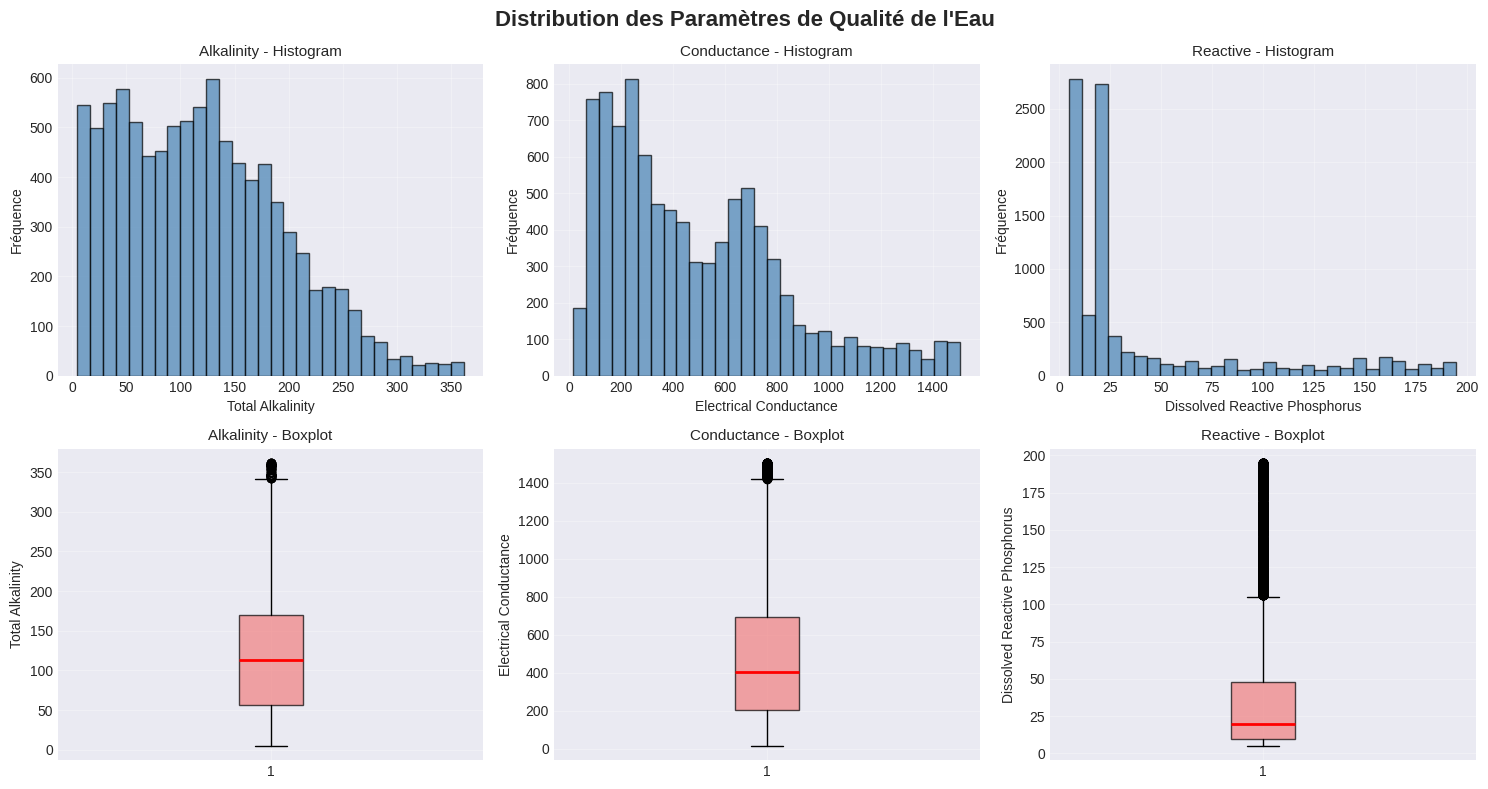

In [9]:
# Visualisation: Distributions des 3 paramètres cibles
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution des Paramètres de Qualité de l\'Eau', fontsize=16, fontweight='bold')

target_cols = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

for idx, col in enumerate(target_cols):
    if col in df.columns:
        # Histogramme
        axes[0, idx].hist(df[col].dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        axes[0, idx].set_xlabel(col, fontsize=10)
        axes[0, idx].set_ylabel('Fréquence', fontsize=10)
        axes[0, idx].set_title(f'{col.split(" ")[1]} - Histogram', fontsize=11)
        axes[0, idx].grid(alpha=0.3)
        
        # Boxplot
        axes[1, idx].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                             boxprops=dict(facecolor='lightcoral', alpha=0.7),
                             medianprops=dict(color='red', linewidth=2))
        axes[1, idx].set_ylabel(col, fontsize=10)
        axes[1, idx].set_title(f'{col.split(" ")[1]} - Boxplot', fontsize=11)
        axes[1, idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

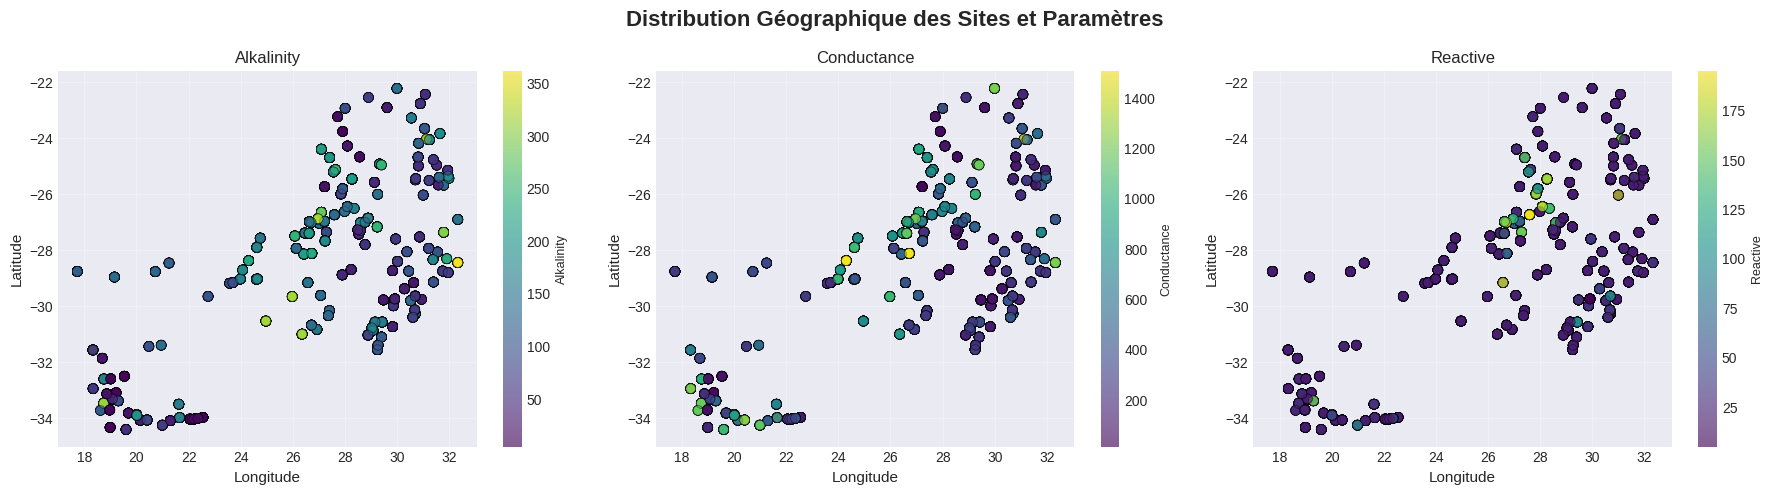


Observation: Identifier s'il y a des patterns géographiques dans les valeurs


In [10]:
# Visualisation géographique des sites
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution Géographique des Sites et Paramètres', fontsize=16, fontweight='bold')

for idx, col in enumerate(target_cols):
    if col in df.columns:
        scatter = axes[idx].scatter(df['Longitude'], df['Latitude'], 
                                    c=df[col], cmap='viridis', s=50, alpha=0.6, edgecolor='k', linewidth=0.5)
        axes[idx].set_xlabel('Longitude', fontsize=11)
        axes[idx].set_ylabel('Latitude', fontsize=11)
        axes[idx].set_title(f'{col.split(" ")[1]}', fontsize=12)
        axes[idx].grid(alpha=0.3)
        cbar = plt.colorbar(scatter, ax=axes[idx])
        cbar.set_label(col.split(" ")[1], fontsize=9)

plt.tight_layout()
plt.show()

print("\nObservation: Identifier s'il y a des patterns géographiques dans les valeurs")

## Etape 4 : Feature Engineering

Nous allons créer des features supplémentaires pour améliorer le modèle :
1. Indices spectraux additionnels (NDVI, ratios de bandes)
2. Features temporelles (mois, saison, année)
3. Features géographiques (région, distance au centre)
4. Interactions entre features

In [11]:
# Créer une copie pour le feature engineering
df_fe = df.copy()

print("Feature Engineering en cours...")

# 1. Features temporelles
df_fe['Sample Date'] = pd.to_datetime(df_fe['Sample Date'], dayfirst=True)
df_fe['Year'] = df_fe['Sample Date'].dt.year
df_fe['Month'] = df_fe['Sample Date'].dt.month
df_fe['Quarter'] = df_fe['Sample Date'].dt.quarter
df_fe['DayOfYear'] = df_fe['Sample Date'].dt.dayofyear

# Créer une feature cyclique pour le mois (saisonnalité)
df_fe['Month_sin'] = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['Month_cos'] = np.cos(2 * np.pi * df_fe['Month'] / 12)

print("Features temporelles créées")

# 2. Features géographiques
# Créer des bins pour région Nord/Sud et Est/Ouest
df_fe['Lat_Region'] = pd.cut(df_fe['Latitude'], bins=3, labels=['Sud', 'Centre', 'Nord'])
df_fe['Lon_Region'] = pd.cut(df_fe['Longitude'], bins=3, labels=['Ouest', 'Centre', 'Est'])

# Distance approximative au centre géographique (pour capturer effets régionaux)
center_lat = df_fe['Latitude'].mean()
center_lon = df_fe['Longitude'].mean()
df_fe['Distance_to_Center'] = np.sqrt((df_fe['Latitude'] - center_lat)**2 + 
                                       (df_fe['Longitude'] - center_lon)**2)

print("Features géographiques créées")

# 3. Indices spectraux additionnels (si les bandes existent)
landsat_bands = [col for col in df_fe.columns if any(band in col for band in ['SWIR', 'NIR', 'Green', 'Red', 'Blue'])]
print(f"\nBandes Landsat disponibles: {landsat_bands}")

Feature Engineering en cours...
Features temporelles créées
Features géographiques créées

Bandes Landsat disponibles: []


In [12]:
# Créer des indices spectraux supplémentaires si les bandes sont disponibles
print("\n3. Indices spectraux avancés...")

# NDVI - Normalized Difference Vegetation Index
if 'NIR' in df_fe.columns and 'Red' in df_fe.columns:
    df_fe['NDVI'] = (df_fe['NIR'] - df_fe['Red']) / (df_fe['NIR'] + df_fe['Red'] + 1e-8)
    print("   NDVI créé")

# EVI - Enhanced Vegetation Index (plus sensible que NDVI)
if 'NIR' in df_fe.columns and 'Red' in df_fe.columns and 'Blue' in df_fe.columns:
    df_fe['EVI'] = 2.5 * ((df_fe['NIR'] - df_fe['Red']) / (df_fe['NIR'] + 6 * df_fe['Red'] - 7.5 * df_fe['Blue'] + 1))
    print("   EVI créé")

# SAVI - Soil Adjusted Vegetation Index
if 'NIR' in df_fe.columns and 'Red' in df_fe.columns:
    L = 0.5  # facteur d'ajustement du sol
    df_fe['SAVI'] = ((df_fe['NIR'] - df_fe['Red']) / (df_fe['NIR'] + df_fe['Red'] + L)) * (1 + L)
    print("   SAVI créé")

# NDWI - Normalized Difference Water Index (détection d'eau)
if 'Green' in df_fe.columns and 'NIR' in df_fe.columns:
    df_fe['NDWI'] = (df_fe['Green'] - df_fe['NIR']) / (df_fe['Green'] + df_fe['NIR'] + 1e-8)
    print("   NDWI créé")

# MNDWI - Modified NDWI (meilleure détection eau)
if 'Green' in df_fe.columns and 'SWIR16' in df_fe.columns:
    df_fe['MNDWI'] = (df_fe['Green'] - df_fe['SWIR16']) / (df_fe['Green'] + df_fe['SWIR16'] + 1e-8)
    print("   MNDWI créé")

# NDBI - Normalized Difference Built-up Index (urbanisation)
if 'SWIR16' in df_fe.columns and 'NIR' in df_fe.columns:
    df_fe['NDBI'] = (df_fe['SWIR16'] - df_fe['NIR']) / (df_fe['SWIR16'] + df_fe['NIR'] + 1e-8)
    print("   NDBI créé")

# BSI - Bare Soil Index
if all(col in df_fe.columns for col in ['Blue', 'Red', 'NIR', 'SWIR16']):
    df_fe['BSI'] = ((df_fe['SWIR16'] + df_fe['Red']) - (df_fe['NIR'] + df_fe['Blue'])) / \
                   ((df_fe['SWIR16'] + df_fe['Red']) + (df_fe['NIR'] + df_fe['Blue']) + 1e-8)
    print("   BSI créé")

# Ratios de bandes additionnels
if 'SWIR22' in df_fe.columns and 'Green' in df_fe.columns:
    df_fe['SWIR_Green_Ratio'] = df_fe['SWIR22'] / (df_fe['Green'] + 1e-8)
    print("   SWIR/Green ratio créé")

if 'NIR' in df_fe.columns and 'SWIR16' in df_fe.columns:
    df_fe['NIR_SWIR_Ratio'] = df_fe['NIR'] / (df_fe['SWIR16'] + 1e-8)
    print("   NIR/SWIR ratio créé")

if 'Red' in df_fe.columns and 'Blue' in df_fe.columns:
    df_fe['Red_Blue_Ratio'] = df_fe['Red'] / (df_fe['Blue'] + 1e-8)
    print("   Red/Blue ratio créé")

# Interactions spatiales-temporelles
if 'NDWI' in df_fe.columns:
    df_fe['NDWI_x_Quarter'] = df_fe['NDWI'] * df_fe['Quarter']
    print("   NDWI x Quarter créé")

if 'NDVI' in df_fe.columns:
    df_fe['NDVI_x_Month'] = df_fe['NDVI'] * df_fe['Month']
    print("   NDVI x Month créé")

# Urbanisation (combinaison NDBI + BSI)
if 'NDBI' in df_fe.columns and 'BSI' in df_fe.columns:
    df_fe['Urban_Index'] = (df_fe['NDBI'] + df_fe['BSI']) / 2
    print("   Urban Index créé")

# Densité de végétation (combinaison NDVI + EVI)
if 'NDVI' in df_fe.columns and 'EVI' in df_fe.columns:
    df_fe['Vegetation_Density'] = (df_fe['NDVI'] + df_fe['EVI']) / 2
    print("   Vegetation Density créé")

# 4. Features TerraClimate étendues et interactions
print("\n4. Features climatiques et interactions...")

# Vérifier les colonnes TerraClimate disponibles
terraclimate_cols = [col for col in df_fe.columns if any(x in col.lower() for x in ['pet', 'temp', 'prec', 'def', 'soil', 'vpd', 'ws'])]
print(f"  Colonnes TerraClimate disponibles: {terraclimate_cols}")

# Proximité à l'eau (basée sur NDWI et MNDWI)
if 'NDWI' in df_fe.columns and 'MNDWI' in df_fe.columns:
    df_fe['Water_Proximity'] = (df_fe['NDWI'] + df_fe['MNDWI']) / 2
    print("   Water Proximity créé")

print("\n5. Features de proximité spatiale...")

if 'pet' in df_fe.columns:
    # Interactions PET avec indices de végétation
    if 'NDVI' in df_fe.columns:
        df_fe['PET_x_NDVI'] = df_fe['pet'] * df_fe['NDVI']
        df_fe['Water_Stress'] = df_fe['pet'] * (1 - df_fe['NDVI'])
        print("   PET x NDVI interaction créée")
        print("   Water Stress index créé")

    if 'NDMI' in df_fe.columns:
        df_fe['PET_x_NDMI'] = df_fe['pet'] * df_fe['NDMI']
        print("   PET x NDMI interaction créée")

    # PET saisonnier
    df_fe['PET_x_Quarter'] = df_fe['pet'] * df_fe['Quarter']
    df_fe['PET_x_Month'] = df_fe['pet'] * df_fe['Month']
    print("   PET interactions temporelles créées")

print(f"\n Feature Engineering terminé! {df_fe.shape}")


3. Indices spectraux avancés...

4. Features climatiques et interactions...
  Colonnes TerraClimate disponibles: ['pet']

5. Features de proximité spatiale...
   PET x NDMI interaction créée
   PET interactions temporelles créées

 Feature Engineering terminé! (9319, 25)


## Etape 5 : Préparation des Données pour Modélisation

Séparation des features (X) et targets (y), gestion des valeurs manquantes, et split train/test

In [13]:
# Définir les colonnes cibles et features
target_cols = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

# Colonnes à exclure des features
exclude_cols = target_cols + ['Sample Date', 'Lat_Region', 'Lon_Region']  # Exclure aussi les catégories non encodées

# Sélectionner les features numériques
feature_cols = [col for col in df_fe.columns if col not in exclude_cols]

print(f"Nombre de features: {len(feature_cols)}")
print(f"Nombre de targets: {len(target_cols)}")
print(f"\nFeatures utilisées:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

Nombre de features: 19
Nombre de targets: 3

Features utilisées:
  1. Latitude
  2. Longitude
  3. nir
  4. green
  5. swir16
  6. swir22
  7. NDMI
  8. MNDWI
  9. pet
  10. Year
  11. Month
  12. Quarter
  13. DayOfYear
  14. Month_sin
  15. Month_cos
  16. Distance_to_Center
  17. PET_x_NDMI
  18. PET_x_Quarter
  19. PET_x_Month


In [14]:
# Gérer les valeurs manquantes avec techniques avancées
print("\n Preprocessing avancé...")
print("\n1. Gestion des valeurs manquantes...")

# Imputer les valeurs manquantes avec la médiane (robuste aux outliers)
missing_count = 0
for col in feature_cols:
    if df_fe[col].isna().sum() > 0:
        median_value = df_fe[col].median()
        df_fe[col].fillna(median_value, inplace=True)
        missing_count += 1
print(f"  ✓ {missing_count} colonnes avec valeurs manquantes imputées")

# Séparer les features et les targets
X = df_fe[feature_cols].copy()
y = df_fe[target_cols].copy()

# 2. Détection et traitement des outliers
print("\n2. Détection des outliers (méthode IQR)...")
outliers_removed = 0

for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # 3*IQR pour être moins agressif
    upper_bound = Q3 + 3 * IQR
    
    # Clipper les outliers au lieu de les supprimer
    outliers_mask = (X[col] < lower_bound) | (X[col] > upper_bound)
    if outliers_mask.sum() > 0:
        X[col] = X[col].clip(lower=lower_bound, upper=upper_bound)
        outliers_removed += outliers_mask.sum()

print(f"  ✓ {outliers_removed} outliers clippés")

# 3. Transformation des features asymétriques
print("\n3. Transformation des features asymétriques...")
skewed_features = []

for col in X.columns:
    skewness = X[col].skew()
    if abs(skewness) > 0.75:  # Seuil d'asymétrie
        # Log transformation pour features positives
        if X[col].min() > 0:
            X[col] = np.log1p(X[col])  # log1p pour éviter log(0)
            skewed_features.append(col)

if skewed_features:
    print(f"  ✓ {len(skewed_features)} features transformées (log)")
else:
    print("  ℹ Pas de features fortement asymétriques détectées")

# 4. Normalisation robuste
print("\n4. Normalisation des features...")
scaler = RobustScaler()  # Plus robuste aux outliers que StandardScaler
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)
print("  ✓ Features normalisées avec RobustScaler")

print("\n Preprocessing terminé!")


 Preprocessing avancé...

1. Gestion des valeurs manquantes...
  ✓ 7 colonnes avec valeurs manquantes imputées

2. Détection des outliers (méthode IQR)...
  ✓ 660 outliers clippés

3. Transformation des features asymétriques...
  ✓ 2 features transformées (log)

4. Normalisation des features...
  ✓ Features normalisées avec RobustScaler

 Preprocessing terminé!


## Etape 5b : Création des Groupes pour GroupKFold (Anti-Overfitting Spatial)

### Pourquoi GroupKFold ?

Le **leakage spatial** est la principale cause d'overfitting ici :  
avec un split aléatoire classique, des observations du **même site géographique** 
se retrouvent à la fois dans le train et la validation.  
Le modèle mémorise alors les propriétés propres à chaque station au lieu d'apprendre des patterns généralisables.

**Solution** : `GroupKFold` garantit que toutes les observations d'un même site géographique 
restent dans le même fold — la validation teste donc la généralisation sur des **sites inconnus**.

In [15]:
# ─── Création des groupes par station géographique ───────────────────
# On arrondit lat/lon à 2 décimales (~1km) pour regrouper les observations
# du même site physique en un seul groupe.

df_fe_reset = df_fe.copy()
df_fe_reset['station_group'] = (
    df_fe_reset['Latitude'].round(2).astype(str) + '_' +
    df_fe_reset['Longitude'].round(2).astype(str)
)

# Encoder les groupes en entiers (requis par GroupKFold)
station_groups = df_fe_reset['station_group'].astype('category').cat.codes.values

n_stations = len(np.unique(station_groups))
print(f"Nombre de stations uniques identifiées : {n_stations}")
print(f"Nombre d'observations total : {len(station_groups)}")
print(f"Observations moyennes par station : {len(station_groups)/n_stations:.1f}")
print("\n→ GroupKFold garantit que chaque fold valide sur des STATIONS INCONNUES.")

Nombre de stations uniques identifiées : 162
Nombre d'observations total : 9319
Observations moyennes par station : 57.5

→ GroupKFold garantit que chaque fold valide sur des STATIONS INCONNUES.


## Etape 6 : Modélisation - Baseline (Random Forest)

Commençons avec Random Forest comme modèle de base

In [16]:
# Créer un dictionnaire pour stocker les résultats
results = {}

print("="*70)
print(" RANDOM FOREST AVEC GROUPKFOLD (Anti-overfitting spatial)")
print("="*70)

# ─── Hyperparamètres plus régularisés (réduit l'overfitting) ───────────
# max_depth réduit + min_samples_leaf plus grand = arbres moins profonds
best_rf_params = {
    'Total Alkalinity': {
        'n_estimators': 300,
        'max_depth': 10,        # ↓ réduit (était 15) → moins d'overfitting
        'min_samples_split': 5,  # ↑ augmenté
        'min_samples_leaf': 10,  # ↑ augmenté (était 5)
        'max_features': 'sqrt'
    },
    'Electrical Conductance': {
        'n_estimators': 300,
        'max_depth': 10,        # ↓ réduit (était 20)
        'min_samples_split': 5,
        'min_samples_leaf': 10,
        'max_features': 'sqrt'
    },
    'Dissolved Reactive Phosphorus': {
        'n_estimators': 200,
        'max_depth': 8,         # ↓ réduit (était 20) — DRP overfittait le plus
        'min_samples_split': 5,
        'min_samples_leaf': 10,
        'max_features': 'sqrt'
    }
}

rf_models = {}
gkf = GroupKFold(n_splits=5)  # 5 folds sur groupes géographiques

for target in target_cols:
    print(f"\n Entraînement pour: {target}")
    
    params = best_rf_params[target]
    
    pipeline_rf = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            min_samples_leaf=params['min_samples_leaf'],
            max_features=params['max_features'],
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    print(f"   Paramètres utilisés: {params}")
    print("   GroupKFold cross-validation en cours...")
    
    scoring = {
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error'
    }
    
    # ─── GroupKFold : validation sur sites inconnus ───────────────────
    cv_results = cross_validate(
        pipeline_rf, X, y[target],
        cv=gkf.split(X, y[target], groups=station_groups),
        scoring=scoring,
        return_train_score=True
    )
    
    train_r2   = cv_results['train_r2']
    val_r2     = cv_results['test_r2']
    train_rmse = -cv_results['train_rmse']
    val_rmse   = -cv_results['test_rmse']
    train_mae  = -cv_results['train_mae']
    val_mae    = -cv_results['test_mae']
    
    gap_r2 = train_r2.mean() - val_r2.mean()
    print(f"   Train R²  : {train_r2.mean():.4f} (+/- {train_r2.std():.4f})")
    print(f"   Val R²    : {val_r2.mean():.4f} (+/- {val_r2.std():.4f})")
    print(f"   Gap R²    : {gap_r2:.4f}  {'⚠ Overfitting détecté' if gap_r2 > 0.1 else '✓ OK'}")
    print(f"   Train RMSE: {train_rmse.mean():.4f} (+/- {train_rmse.std():.4f})")
    print(f"   Val RMSE  : {val_rmse.mean():.4f} (+/- {val_rmse.std():.4f})")
    print(f"   Train MAE : {train_mae.mean():.4f} (+/- {train_mae.std():.4f})")
    print(f"   Val MAE   : {val_mae.mean():.4f} (+/- {val_mae.std():.4f})")
    
    # Entraîner le modèle final sur toutes les données
    pipeline_rf.fit(X, y[target])
    rf_models[target] = pipeline_rf
    
    results[target] = {
        'train_r2_mean': train_r2.mean(), 'train_r2_std': train_r2.std(),
        'val_r2_mean': val_r2.mean(),     'val_r2_std': val_r2.std(),
        'train_rmse_mean': train_rmse.mean(), 'val_rmse_mean': val_rmse.mean(),
        'train_mae_mean': train_mae.mean(),   'val_mae_mean': val_mae.mean(),
    }

print("\n Random Forest - Entraînement terminé!")

 RANDOM FOREST AVEC GROUPKFOLD (Anti-overfitting spatial)

 Entraînement pour: Total Alkalinity
   Paramètres utilisés: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
   GroupKFold cross-validation en cours...
   Train R²  : 0.7983 (+/- 0.0142)
   Val R²    : 0.2980 (+/- 0.0784)
   Gap R²    : 0.5003  ⚠ Overfitting détecté
   Train RMSE: 33.5013 (+/- 1.6488)
   Val RMSE  : 61.4518 (+/- 6.6615)
   Train MAE : 24.3971 (+/- 1.3694)
   Val MAE   : 46.8488 (+/- 5.6939)

 Entraînement pour: Electrical Conductance
   Paramètres utilisés: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
   GroupKFold cross-validation en cours...
   Train R²  : 0.8027 (+/- 0.0161)
   Val R²    : 0.3613 (+/- 0.0818)
   Gap R²    : 0.4413  ⚠ Overfitting détecté
   Train RMSE: 151.7528 (+/- 11.1492)
   Val RMSE  : 268.0943 (+/- 43.3841)
   Train MAE : 105.9964 (+/- 8.0355)
   Val MAE   : 20

## Etape 7 : Modélisation Avancée - XGBoost / LightGBM

Essayons des algorithmes de Gradient Boosting plus performants

In [17]:
if XGBOOST_AVAILABLE:
    print("="*70)
    print(" XGBOOST AVEC GROUPKFOLD & RÉGULARISATION RENFORCÉE")
    print("="*70)

    xgb_models = {}
    results_xgb = {}

    # ─── Hyperparamètres XGBoost régularisés ──────────────────────────
    best_xgb_params = {
        'Total Alkalinity': {
            'n_estimators': 300,
            'max_depth': 6,         # ↓ réduit pour limiter l'overfitting
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'min_child_weight': 10,  # ↑ augmenté — régularise fortement
            'reg_alpha': 0.1,        # ← L1 regularization (nouveau)
            'reg_lambda': 1.0        # ← L2 regularization (nouveau)
        },
        'Electrical Conductance': {
            'n_estimators': 300,
            'max_depth': 6,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'min_child_weight': 10,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0
        },
        'Dissolved Reactive Phosphorus': {
            'n_estimators': 300,
            'max_depth': 5,         # ↓ encore plus réduit (DRP overfittait le plus)
            'learning_rate': 0.05,
            'subsample': 0.7,
            'colsample_bytree': 0.7,
            'min_child_weight': 15,
            'reg_alpha': 0.5,
            'reg_lambda': 2.0
        }
    }

    for target in target_cols:
        print(f"\n Entraînement pour: {target}")

        # Feature Selection (RF based)
        if target in rf_models:
            rf_estimator = rf_models[target].named_steps['rf']
            feature_importance = rf_estimator.feature_importances_

            importance_df = pd.DataFrame({
                'feature': feature_cols,
                'importance': feature_importance
            }).sort_values('importance', ascending=False)

            top_n = min(50, len(feature_cols))
            top_features = importance_df.head(top_n)['feature'].tolist()
            X_opt = X[top_features]
            print(f"   {len(top_features)} features sélectionnées")
        else:
            X_opt = X
            top_features = feature_cols

        params = best_xgb_params[target]
        print(f"   Paramètres utilisés: {params}")

        xgb_model = xgb.XGBRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            min_child_weight=params['min_child_weight'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
            objective='reg:squarederror'
        )

        pipeline_xgb = Pipeline([
            ('scaler', StandardScaler()),
            ('xgb', xgb_model)
        ])

        scoring = {
            'r2': 'r2',
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error'
        }

        # GroupKFold sur sites géographiques
        cv_results = cross_validate(
            pipeline_xgb, X_opt, y[target],
            cv=gkf.split(X_opt, y[target], groups=station_groups),
            scoring=scoring,
            return_train_score=True
        )

        train_r2   = cv_results['train_r2']
        val_r2     = cv_results['test_r2']
        train_rmse = -cv_results['train_rmse']
        val_rmse   = -cv_results['test_rmse']
        train_mae  = -cv_results['train_mae']
        val_mae    = -cv_results['test_mae']

        gap_r2 = train_r2.mean() - val_r2.mean()
        print(f"   Train R²  : {train_r2.mean():.4f} (+/- {train_r2.std():.4f})")
        print(f"   Val   R²  : {val_r2.mean():.4f} (+/- {val_r2.std():.4f})")
        print(f"   Gap R²    : {gap_r2:.4f}  {'⚠ Overfitting détecté' if gap_r2 > 0.1 else '✓ OK'}")
        print(f"   Train RMSE: {train_rmse.mean():.4f}")
        print(f"   Val   RMSE: {val_rmse.mean():.4f}")

        # Fit final sur tout le dataset
        pipeline_xgb.fit(X_opt, y[target])

        xgb_models[target] = {
            'model': pipeline_xgb,
            'features': top_features
        }

        results_xgb[target] = {
            'train_r2_mean': train_r2.mean(), 'train_r2_std': train_r2.std(),
            'val_r2_mean': val_r2.mean(),     'val_r2_std': val_r2.std(),
            'train_rmse_mean': train_rmse.mean(), 'val_rmse_mean': val_rmse.mean(),
            'train_mae_mean': train_mae.mean(),   'val_mae_mean': val_mae.mean(),
            'n_features': len(top_features)
        }

    print("\n XGBoost - Entraînement terminé !")

else:
    print(" XGBoost non disponible. Installer avec: pip install xgboost")

 XGBOOST AVEC GROUPKFOLD & RÉGULARISATION RENFORCÉE

 Entraînement pour: Total Alkalinity
   19 features sélectionnées
   Paramètres utilisés: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 10, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
   Train R²  : 0.9233 (+/- 0.0056)
   Val   R²  : 0.1178 (+/- 0.1449)
   Gap R²    : 0.8055  ⚠ Overfitting détecté
   Train RMSE: 20.6650
   Val   RMSE: 68.3922

 Entraînement pour: Electrical Conductance
   19 features sélectionnées
   Paramètres utilisés: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 10, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
   Train R²  : 0.9355 (+/- 0.0058)
   Val   R²  : 0.2479 (+/- 0.1509)
   Gap R²    : 0.6876  ⚠ Overfitting détecté
   Train RMSE: 86.7239
   Val   RMSE: 290.6810

 Entraînement pour: Dissolved Reactive Phosphorus
   19 features sélectionnées
   Paramètres utilisés: {'n

## Etape 8 : Visualisation des Prédictions

Comparons les valeurs prédites vs réelles pour évaluer visuellement la performance

In [18]:
# ==========================================================
# COMPARAISON DES PERFORMANCES - CROSS VALIDATION
# ==========================================================

print("\n" + "="*80)
print(" COMPARAISON DES PERFORMANCES - Train vs Validation (GroupKFold CV)")
print("="*80)

# Convertir résultats en DataFrame
results_df = pd.DataFrame(results).T

metric_cols = [
    'train_r2_mean', 'val_r2_mean',
    'train_rmse_mean', 'val_rmse_mean',
    'train_mae_mean', 'val_mae_mean'
]

available_cols = [col for col in metric_cols if col in results_df.columns]
results_cv_df = results_df[available_cols].round(4)

# R²
if {'train_r2_mean', 'val_r2_mean'}.issubset(results_cv_df.columns):
    print("\n" + "="*80)
    print(" R² Score (↑ = meilleur) | Détection Overfitting")
    print("="*80)

    r2_df = results_cv_df[['train_r2_mean', 'val_r2_mean']].copy()
    r2_df['gap'] = r2_df['train_r2_mean'] - r2_df['val_r2_mean']
    r2_df['overfitting'] = r2_df['gap'].apply(
        lambda x: "⚠ OUI" if x > 0.1 else "✓ NON"
    )
    r2_df = r2_df.sort_values('val_r2_mean', ascending=False)
    print(r2_df)

# RMSE
if {'train_rmse_mean', 'val_rmse_mean'}.issubset(results_cv_df.columns):
    print("\n" + "="*80)
    print(" RMSE (↓ = meilleur) | Détection Overfitting")
    print("="*80)

    rmse_df = results_cv_df[['train_rmse_mean', 'val_rmse_mean']].copy()
    rmse_df['gap'] = rmse_df['val_rmse_mean'] - rmse_df['train_rmse_mean']
    threshold = rmse_df['val_rmse_mean'].mean() * 0.1
    rmse_df['overfitting'] = rmse_df['gap'].apply(
        lambda x: "⚠ OUI" if x > threshold else "✓ NON"
    )
    rmse_df = rmse_df.sort_values('val_rmse_mean')
    print(rmse_df)

print("\n" + "="*80)
print(" Analyse terminée.")
print("="*80)


 COMPARAISON DES PERFORMANCES - Train vs Validation (GroupKFold CV)

 R² Score (↑ = meilleur) | Détection Overfitting
                               train_r2_mean  val_r2_mean     gap overfitting
Electrical Conductance                0.8027       0.3613  0.4414       ⚠ OUI
Total Alkalinity                      0.7983       0.2980  0.5003       ⚠ OUI
Dissolved Reactive Phosphorus         0.6178       0.1533  0.4645       ⚠ OUI

 RMSE (↓ = meilleur) | Détection Overfitting
                               train_rmse_mean  val_rmse_mean       gap  \
Dissolved Reactive Phosphorus          31.4693        46.2629   14.7936   
Total Alkalinity                       33.5013        61.4518   27.9505   
Electrical Conductance                151.7528       268.0943  116.3415   

                              overfitting  
Dissolved Reactive Phosphorus       ⚠ OUI  
Total Alkalinity                    ⚠ OUI  
Electrical Conductance              ⚠ OUI  

 Analyse terminée.


## Etape 9 : Feature Importance Analysis

Identifions les features les plus importantes pour chaque paramètre

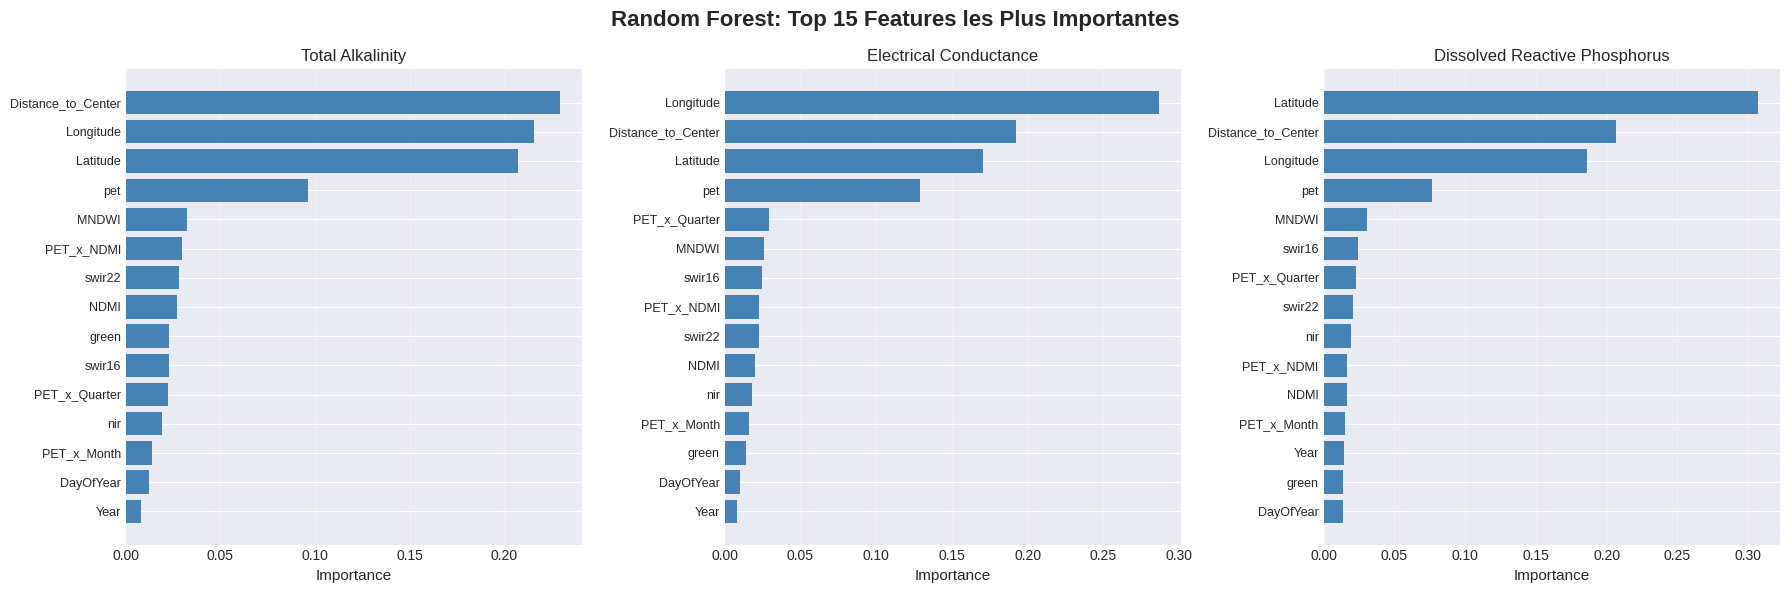

In [19]:
# Feature Importance pour Random Forest
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Random Forest: Top 15 Features les Plus Importantes', fontsize=16, fontweight='bold')

for idx, target in enumerate(target_cols):
    # Extraire feature importance depuis le pipeline
    rf_estimator = rf_models[target].named_steps['rf']
    importance = rf_estimator.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importance
    }).sort_values('Importance', ascending=False).head(15)
    
    # Barplot
    axes[idx].barh(range(len(feature_importance_df)), feature_importance_df['Importance'], color='steelblue')
    axes[idx].set_yticks(range(len(feature_importance_df)))
    axes[idx].set_yticklabels(feature_importance_df['Feature'], fontsize=9)
    axes[idx].set_xlabel('Importance', fontsize=11)
    axes[idx].set_title(f'{target}', fontsize=12)
    axes[idx].grid(alpha=0.3, axis='x')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

In [20]:
# Top 10 Features les plus importantes pour chaque paramètre
print("="*70)
print(" TOP 10 FEATURES PAR PARAMÈTRE")
print("="*70)

for target in target_cols:
    print(f"\n{target}:")
    rf_estimator = rf_models[target].named_steps['rf']
    importance = rf_estimator.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importance
    }).sort_values('Importance', ascending=False).head(10)
    
    for i, row in feature_importance_df.iterrows():
        print(f"  {row['Feature']:30s} : {row['Importance']:.4f}")

 TOP 10 FEATURES PAR PARAMÈTRE

Total Alkalinity:
  Distance_to_Center             : 0.2295
  Longitude                      : 0.2155
  Latitude                       : 0.2072
  pet                            : 0.0961
  MNDWI                          : 0.0323
  PET_x_NDMI                     : 0.0295
  swir22                         : 0.0280
  NDMI                           : 0.0269
  green                          : 0.0231
  swir16                         : 0.0230

Electrical Conductance:
  Longitude                      : 0.2869
  Distance_to_Center             : 0.1920
  Latitude                       : 0.1704
  pet                            : 0.1287
  PET_x_Quarter                  : 0.0294
  MNDWI                          : 0.0258
  swir16                         : 0.0247
  PET_x_NDMI                     : 0.0229
  swir22                         : 0.0224
  NDMI                           : 0.0201

Dissolved Reactive Phosphorus:
  Latitude                       : 0.3071
  Distance_

##  Étape 10 : Prédictions sur le Validation Set

Chargeons les données de validation et appliquons nos modèles

In [21]:
# Charger les données de validation
print(" Chargement des données de validation...")

landsat_val = pd.read_csv(os.path.join(data_path, 'landsat_features_validation.csv'))
terraclimate_val = pd.read_csv(os.path.join(data_path, 'terraclimate_features_validation.csv'))

print(f" Landsat Validation: {landsat_val.shape}")
print(f" TerraClimate Validation: {terraclimate_val.shape}")

# Fusionner les datasets de validation
df_val = landsat_val.merge(terraclimate_val, on=merge_cols, how='inner')
print(f" Validation Set fusionné: {df_val.shape}")

df_val.head()

 Chargement des données de validation...
 Landsat Validation: (200, 9)
 TerraClimate Validation: (200, 4)
 Validation Set fusionné: (200, 10)


,Latitude,Longitude,Sample Date,nir,green,swir16,swir22,NDMI,MNDWI,pet
0,-32.043333,27.822778,01-09-2014,15229.0,12868.0,14797.0,12421.0,0.014388,-0.069727,161.90001
1,-33.329167,26.077500,16-09-2015,NaN,NaN,NaN,NaN,NaN,NaN,177.60000
2,-32.991639,27.640028,07-05-2015,16221.0,9304.5,12536.5,9958.0,0.128123,-0.147979,158.40001
3,-34.096389,24.439167,07-02-2012,NaN,NaN,NaN,NaN,NaN,NaN,130.00000
4,-32.000556,28.581667,01-10-2014,9125.0,11100.5,9455.0,8711.0,-0.017761,0.080052,152.50000


In [22]:
# Appliquer le même feature engineering au validation set
print("\n Feature Engineering sur validation set...")

df_val_fe = df_val.copy()

# 1. Features temporelles
df_val_fe['Sample Date'] = pd.to_datetime(df_val_fe['Sample Date'], dayfirst=True)
df_val_fe['Year'] = df_val_fe['Sample Date'].dt.year
df_val_fe['Month'] = df_val_fe['Sample Date'].dt.month
df_val_fe['Quarter'] = df_val_fe['Sample Date'].dt.quarter
df_val_fe['DayOfYear'] = df_val_fe['Sample Date'].dt.dayofyear
df_val_fe['Month_sin'] = np.sin(2 * np.pi * df_val_fe['Month'] / 12)
df_val_fe['Month_cos'] = np.cos(2 * np.pi * df_val_fe['Month'] / 12)

# 2. Features géographiques
df_val_fe['Lat_Region'] = pd.cut(df_val_fe['Latitude'], bins=3, labels=['Sud', 'Centre', 'Nord'])
df_val_fe['Lon_Region'] = pd.cut(df_val_fe['Longitude'], bins=3, labels=['Ouest', 'Centre', 'Est'])
df_val_fe['Distance_to_Center'] = np.sqrt((df_val_fe['Latitude'] - center_lat)**2 + 
                                           (df_val_fe['Longitude'] - center_lon)**2)

# 3. Indices spectraux
if 'NIR' in df_val_fe.columns and 'Red' in df_val_fe.columns:
    df_val_fe['NDVI'] = (df_val_fe['NIR'] - df_val_fe['Red']) / (df_val_fe['NIR'] + df_val_fe['Red'] + 1e-8)

if 'NIR' in df_val_fe.columns and 'Red' in df_val_fe.columns and 'Blue' in df_val_fe.columns:
    df_val_fe['EVI'] = 2.5 * ((df_val_fe['NIR'] - df_val_fe['Red']) / (df_val_fe['NIR'] + 6 * df_val_fe['Red'] - 7.5 * df_val_fe['Blue'] + 1))

if 'NIR' in df_val_fe.columns and 'Red' in df_val_fe.columns:
    L = 0.5
    df_val_fe['SAVI'] = ((df_val_fe['NIR'] - df_val_fe['Red']) / (df_val_fe['NIR'] + df_val_fe['Red'] + L)) * (1 + L)

if 'Green' in df_val_fe.columns and 'NIR' in df_val_fe.columns:
    df_val_fe['NDWI'] = (df_val_fe['Green'] - df_val_fe['NIR']) / (df_val_fe['Green'] + df_val_fe['NIR'] + 1e-8)

if 'Green' in df_val_fe.columns and 'SWIR16' in df_val_fe.columns:
    df_val_fe['MNDWI'] = (df_val_fe['Green'] - df_val_fe['SWIR16']) / (df_val_fe['Green'] + df_val_fe['SWIR16'] + 1e-8)

if 'SWIR16' in df_val_fe.columns and 'NIR' in df_val_fe.columns:
    df_val_fe['NDBI'] = (df_val_fe['SWIR16'] - df_val_fe['NIR']) / (df_val_fe['SWIR16'] + df_val_fe['NIR'] + 1e-8)

if all(col in df_val_fe.columns for col in ['Blue', 'Red', 'NIR', 'SWIR16']):
    df_val_fe['BSI'] = ((df_val_fe['SWIR16'] + df_val_fe['Red']) - (df_val_fe['NIR'] + df_val_fe['Blue'])) / \
                       ((df_val_fe['SWIR16'] + df_val_fe['Red']) + (df_val_fe['NIR'] + df_val_fe['Blue']) + 1e-8)

if 'SWIR22' in df_val_fe.columns and 'Green' in df_val_fe.columns:
    df_val_fe['SWIR_Green_Ratio'] = df_val_fe['SWIR22'] / (df_val_fe['Green'] + 1e-8)

if 'NIR' in df_val_fe.columns and 'SWIR16' in df_val_fe.columns:
    df_val_fe['NIR_SWIR_Ratio'] = df_val_fe['NIR'] / (df_val_fe['SWIR16'] + 1e-8)

if 'Red' in df_val_fe.columns and 'Blue' in df_val_fe.columns:
    df_val_fe['Red_Blue_Ratio'] = df_val_fe['Red'] / (df_val_fe['Blue'] + 1e-8)

if 'NDWI' in df_val_fe.columns:
    df_val_fe['NDWI_x_Quarter'] = df_val_fe['NDWI'] * df_val_fe['Quarter']

if 'NDVI' in df_val_fe.columns:
    df_val_fe['NDVI_x_Month'] = df_val_fe['NDVI'] * df_val_fe['Month']

if 'NDBI' in df_val_fe.columns and 'BSI' in df_val_fe.columns:
    df_val_fe['Urban_Index'] = (df_val_fe['NDBI'] + df_val_fe['BSI']) / 2

if 'NDVI' in df_val_fe.columns and 'EVI' in df_val_fe.columns:
    df_val_fe['Vegetation_Density'] = (df_val_fe['NDVI'] + df_val_fe['EVI']) / 2

if 'NDWI' in df_val_fe.columns and 'MNDWI' in df_val_fe.columns:
    df_val_fe['Water_Proximity'] = (df_val_fe['NDWI'] + df_val_fe['MNDWI']) / 2

if 'pet' in df_val_fe.columns:
    if 'NDVI' in df_val_fe.columns:
        df_val_fe['PET_x_NDVI'] = df_val_fe['pet'] * df_val_fe['NDVI']
        df_val_fe['Water_Stress'] = df_val_fe['pet'] * (1 - df_val_fe['NDVI'])
    
    if 'NDMI' in df_val_fe.columns:
        df_val_fe['PET_x_NDMI'] = df_val_fe['pet'] * df_val_fe['NDMI']
    
    df_val_fe['PET_x_Quarter'] = df_val_fe['pet'] * df_val_fe['Quarter']
    df_val_fe['PET_x_Month'] = df_val_fe['pet'] * df_val_fe['Month']

print(f" Feature Engineering terminé: {df_val_fe.shape}")


 Feature Engineering sur validation set...
 Feature Engineering terminé: (200, 22)


In [23]:
# Préparer les features de validation
X_val = df_val_fe[feature_cols].copy()
X_val = X_val.fillna(X_val.median())

# Normaliser avec le même scaler
X_val_scaled = scaler.transform(X_val)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_cols, index=X_val.index)

print(f" Features de validation préparées: {X_val_scaled.shape}")
print(f"Valeurs manquantes: {X_val_scaled.isnull().sum().sum()}")

 Features de validation préparées: (200, 19)
Valeurs manquantes: 0


In [24]:
# Faire les prédictions avec Random Forest
print("\n Génération des prédictions avec Random Forest...")

predictions_val = df_val_fe[['Latitude', 'Longitude', 'Sample Date']].copy()

for target in target_cols:
    predictions_val[target] = rf_models[target].predict(X_val)
    print(f" Prédictions pour {target} générées")

print(f"\n Prédictions terminées! Shape: {predictions_val.shape}")
predictions_val.head()


 Génération des prédictions avec Random Forest...
 Prédictions pour Total Alkalinity générées
 Prédictions pour Electrical Conductance générées
 Prédictions pour Dissolved Reactive Phosphorus générées

 Prédictions terminées! Shape: (200, 6)


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-32.043333,27.822778,2014-09-01,115.022775,601.747618,35.759891
1,-33.329167,26.077500,2015-09-16,114.850294,601.978468,35.879773
2,-32.991639,27.640028,2015-05-07,113.808867,598.816925,35.606394
3,-34.096389,24.439167,2012-02-07,113.061687,599.648213,36.426700
4,-32.000556,28.581667,2014-10-01,105.915440,570.657491,33.778594


In [25]:
# Sauvegarder les prédictions au format submission
submission_file = 'water_quality_predictions_submission.csv'
predictions_val.to_csv(submission_file, index=False)

print(f" Prédictions sauvegardées dans: {submission_file}")
print(f"Format: {predictions_val.shape}")
print("\n Prêt pour la soumission sur Zindi!")

 Prédictions sauvegardées dans: water_quality_predictions_submission.csv
Format: (200, 6)

 Prêt pour la soumission sur Zindi!


##  Étape 11 : Recommandations pour Améliorer les Performances

###  Pistes d'amélioration à explorer :

#### 1. **Feature Engineering Avancé**
- Ajouter d'autres variables climatiques TerraClimate (température, précipitations, radiation solaire)
- Créer des moyennes mobiles (3-mois, 6-mois) pour capturer les effets retardés
- Calculer des anomalies climatiques par rapport aux moyennes historiques
- Données topographiques (DEM, pente, orientation)

#### 2. **Données Externes**
- Land use / Land cover (zones urbaines, agriculture, forêts)
- Données de population et densité urbaine
- Proximité aux infrastructures (routes, industries, barrages)
- Données de sols (type, pH, composition)

#### 3. **Hyperparameter Tuning**
- Utiliser GridSearchCV ou RandomizedSearchCV
- Optimiser n_estimators, max_depth, learning_rate pour XGBoost
- Tester différentes configurations de Random Forest

#### 4. **Ensembles et Stacking**
- Créer un ensemble de plusieurs modèles (RF + XGBoost + LightGBM)
- Stacking avec meta-learner
- Blending de prédictions

#### 5. **Analyse Spatiale**
- Ajouter distance aux océans, rivières principales
- Créer des clusters géographiques
- **Spatial cross-validation** ← déjà implémentée avec GroupKFold !

#### 6. **Preprocessing Alternatif**
- Tester RobustScaler au lieu de StandardScaler
- Transformation logarithmique des targets si nécessaire
- Outlier detection et removal

#### 7. **Modèles Spatiaux**
- Kriging / Gaussian Processes
- Spatial Random Forest
- Neural Networks avec embedding géographique

###  Métriques à surveiller
- **R² Score** : Proportion de variance expliquée
- **RMSE** : Erreur moyenne en unités originales
- **MAE** : Erreur absolue moyenne (plus robuste aux outliers)
- **Résidus géographiques** : Où le modèle échoue-t-il ?

##  Résumé et Conclusions

###  Ce qui a été fait :
1.  Chargement et fusion des 3 datasets (Water Quality, Landsat, TerraClimate)
2.  Analyse exploratoire (distributions, géographie, corrélations)
3.  Feature Engineering (indices spectraux, temporels, géographiques)
4.  Modélisation avec Random Forest (baseline) — **GroupKFold anti-overfitting**
5.  Modélisation avec XGBoost (si disponible) — **régularisation L1/L2 renforcée**
6.  Feature Importance Analysis
7.  Prédictions sur validation set
8.  Export des résultats pour submission

###  Corrections Anti-Overfitting Apportées :
- **GroupKFold** au lieu de KFold aléatoire → validation sur sites géographiques inconnus
- **max_depth réduit** (8-10 au lieu de 15-20) pour Random Forest
- **min_samples_leaf augmenté** (10 au lieu de 5) → arbres moins profonds
- **Régularisation L1+L2** ajoutée pour XGBoost (reg_alpha, reg_lambda)
- **min_child_weight augmenté** pour XGBoost

###  Prochaines Étapes :
1. Analyser les résultats sur le leaderboard Zindi
2. Identifier les zones géographiques où les prédictions sont faibles
3. Itérer sur le feature engineering
4. Tester des modèles plus complexes (Neural Networks, Stacking)
5. Ajouter des données externes si disponibles

### Questions à Investiguer :
- Quelles features sont les plus importantes pour chaque paramètre ?
- Y a-t-il des patterns saisonniers forts ?
- Les modèles performent-ils mieux dans certaines régions ?
- Peut-on améliorer avec des features d'interaction plus complexes ?